In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score


In [2]:
import pandas as pd
file_path = "/Users/Aryaanil/Documents/Mall_Customers.csv.xls"
df = pd.read_csv(file_path)
print(df)

     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [3]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [4]:
df = df.dropna()

In [5]:
le = LabelEncoder()

# Convert Gender column into numbers
df['Genre'] = le.fit_transform(df['Genre'])

In [6]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_train, X_test = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (160, 3)
Test Shape: (40, 3)


In [9]:
for k in range(2, 7):

    kmeans = KMeans(n_clusters=k, random_state=42)

    kmeans.fit(X_train)

    clusters = kmeans.predict(X_test)

    score = silhouette_score(X_test, clusters)


In [10]:

    print(f"\nClusters: {k}")
    print("Silhouette Score:", score)


Clusters: 6
Silhouette Score: 0.41456518236731227


In [12]:
kmeans = KMeans(n_clusters=5, random_state=42)

kmeans.fit(X_scaled)
df['Cluster'] = kmeans.predict(X_scaled)


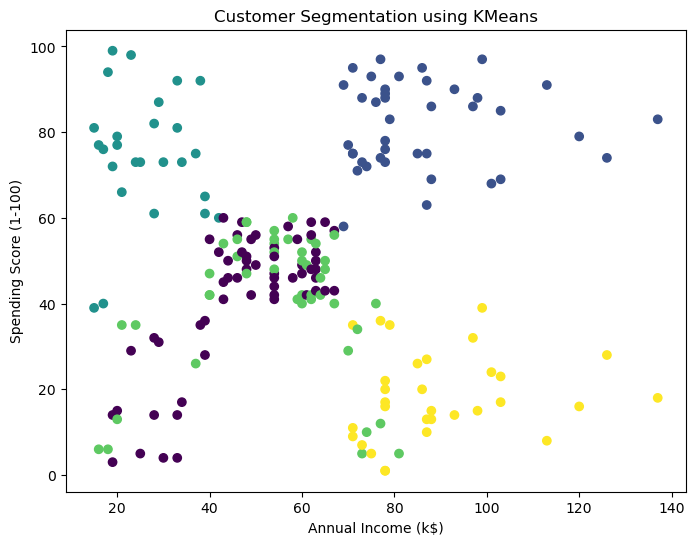

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using KMeans")

plt.show()


In [14]:
print("\nClustered Dataset:")
print(df.head())


Clustered Dataset:
   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1      1   19                  15                      39        2
1           2      1   21                  15                      81        2
2           3      0   20                  16                       6        3
3           4      0   23                  16                      77        2
4           5      0   31                  17                      40        2
